In [ ]:
# setup and imports

!pip install -q segmentation-models-pytorch==0.3.3

import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"  # avoid dynamo/compile weirdness

from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", DEVICE)

# Dataset root in Kaggle
DATA_ROOT = Path("/kaggle/input/seg-dataset")

TRAIN_ORIG_IMG   = DATA_ROOT / "train_dataset"       / "train_dataset"       / "images"
TRAIN_ORIG_MASK  = DATA_ROOT / "train_dataset"       / "train_dataset"       / "masks"

TRAIN_CLEAN_IMG  = DATA_ROOT / "train_dataset_clean" / "train_dataset_clean" / "images"
TRAIN_CLEAN_MASK = DATA_ROOT / "train_dataset_clean" / "train_dataset_clean" / "masks"

VAL_IMG          = DATA_ROOT / "val_dataset"         / "val_dataset"         / "images"
VAL_MASK         = DATA_ROOT / "val_dataset"         / "val_dataset"         / "masks"

print("Orig train images :", len(list(TRAIN_ORIG_IMG.glob('*'))))
print("Orig train masks  :", len(list(TRAIN_ORIG_MASK.glob('*.png'))))
print("Clean train images:", len(list(TRAIN_CLEAN_IMG.glob('*'))))
print("Clean train masks :", len(list(TRAIN_CLEAN_MASK.glob('*.png'))))
print("Val images        :", len(list(VAL_IMG.glob('*'))))
print("Val masks         :", len(list(VAL_MASK.glob('*.png'))))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
Orig train images : 4632
Orig train masks  : 4632
Clean train images: 3334
Clean train masks : 3670
Val images        : 1378
Val masks         : 1378


In [ ]:
# class map and helpers

CLASS_MAP = {
    (255, 255, 255): "background",                         # white
    (1,   88,  255): "sky",                                # blue
    (156, 76,  30):  "rough_trail",                        # brown
    (178, 176, 153): "smooth_trail",                       # light gray
    (128, 255, 0):   "traversable_grass",                  # bright green
    (40,  80,  0):   "high_vegetation",                    # dark green
    (0,   160, 0):   "non_traversable_low_vegetation",     # medium green
    (255, 0,   128): "puddle",                             # magenta
    (255, 0,   0):   "obstacle",                           # red
}

COLOR_LIST  = list(CLASS_MAP.keys())          # [(R,G,B), ...]
CLASS_NAMES = list(CLASS_MAP.values())
NUM_CLASSES = len(COLOR_LIST)

print("NUM_CLASSES:", NUM_CLASSES)
print("CLASSES:", CLASS_NAMES)


def mask_rgb_to_idx(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Convert RGB colour mask to integer mask 0..NUM_CLASSES-1
    mask_rgb: (H,W,3) uint8
    """
    h, w, _ = mask_rgb.shape
    mask_idx = np.zeros((h, w), dtype=np.int64)
    for idx, color in enumerate(COLOR_LIST):
        color_arr = np.array(color, dtype=np.uint8)
        matches = np.all(mask_rgb == color_arr, axis=-1)
        mask_idx[matches] = idx
    return mask_idx


def mask_idx_to_rgb(mask_idx: np.ndarray) -> np.ndarray:
    """
    Convert integer mask back to RGB colour mask.
    mask_idx: (H,W) int
    """
    h, w = mask_idx.shape
    mask_rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, color in enumerate(COLOR_LIST):
        mask_rgb[mask_idx == idx] = color
    return mask_rgb

NUM_CLASSES: 9
CLASSES: ['background', 'sky', 'rough_trail', 'smooth_trail', 'traversable_grass', 'high_vegetation', 'non_traversable_low_vegetation', 'puddle', 'obstacle']


In [ ]:
# compute class statistics + class_weights for the loss
from pathlib import Path

def compute_class_weights(mask_dir):
    """
    Go over all PNG masks in mask_dir, count pixels per class,
    compute percentages and log-inverse-frequency weights,
    then return:
      - class_list: list of class names in CLASS_NAMES order
      - percentage_list: list of percentages per class
      - weights_tensor: torch tensor of class weights (same order)
    """
    mask_dir = Path(mask_dir)

    # count pixels per class
    pixel_counts = {cls: 0 for cls in CLASS_NAMES}

    mask_files = sorted(mask_dir.glob("*.png"))
    for f in tqdm(mask_files, desc="Counting pixels in masks"):
        mask = np.array(Image.open(f).convert("RGB"))
        for color, cls_name in CLASS_MAP.items():
            pixel_counts[cls_name] += int(
                np.sum(
                    np.all(mask == np.array(color, dtype=np.uint8), axis=-1)
                )
            )

    # turn into ordered arrays (CLASS_NAMES order!)
    class_list = list(CLASS_NAMES)
    counts = np.array([pixel_counts[c] for c in class_list], dtype=np.float64)
    total = counts.sum() + 1e-9

    percentage_list = (counts / total) * 100.0
    log_inv = -np.log(counts / total + 1e-9)
    log_inv_norm = log_inv / log_inv.max()

    # base weights from log_inv_norm
    weights = log_inv_norm.copy()

    # BOOST rare classes
    def boost(cls_name, factor):
        if cls_name in class_list:
            idx = class_list.index(cls_name)
            weights[idx] *= factor

    # no boost for "puddle" or "obstacle" anymore
    boost("non_traversable_low_vegetation", 1.3)  # mild boost or set 1.0 to remove (default works better for some reason)

    # slightly down-weight common classes (optional)
    def damp(cls_name, factor):
        if cls_name in class_list:
            idx = class_list.index(cls_name)
            weights[idx] *= factor

    damp("sky", 0.7)
    damp("high_vegetation", 0.7)

    # normalize to have mean ~ 1
    weights /= (weights.mean() + 1e-9)

    # convert to tensor
    weights_tensor = torch.tensor(weights, dtype=torch.float32)

    # pretty print...
    print("Class statistics (original train masks):\n")
    for c, cnt, perc, w in zip(class_list, counts, percentage_list, weights_tensor):
        print(f"{c:35s}  pixels={int(cnt):9d}   perc={perc:6.3f}%   weight={float(w):5.3f}")

    return class_list, percentage_list, weights_tensor


# run on the original train masks
CLASS_LIST, CLASS_PERC, class_weights = compute_class_weights(TRAIN_ORIG_MASK)

print("\nFinal class_weights tensor (used in loss):")
print(class_weights)

Counting pixels in masks: 100%|██████████| 4632/4632 [05:46<00:00, 13.37it/s]

Class statistics (original train masks):

background                           pixels= 14831408   perc= 0.847%   weight=1.409
sky                                  pixels=529325505   perc=30.246%   weight=0.247
rough_trail                          pixels= 78813041   perc= 4.503%   weight=0.916
smooth_trail                         pixels=289976870   perc=16.569%   weight=0.531
traversable_grass                    pixels=417485168   perc=23.855%   weight=0.423
high_vegetation                      pixels=371031722   perc=21.201%   weight=0.321
non_traversable_low_vegetation       pixels= 32365180   perc= 1.849%   weight=1.532
puddle                               pixels=   954359   perc= 0.055%   weight=2.220
obstacle                             pixels= 15304427   perc= 0.874%   weight=1.400

Final class_weights tensor (used in loss):
tensor([1.4093, 0.2473, 0.9159, 0.5310, 0.4234, 0.3208, 1.5325, 2.2198, 1.4001])


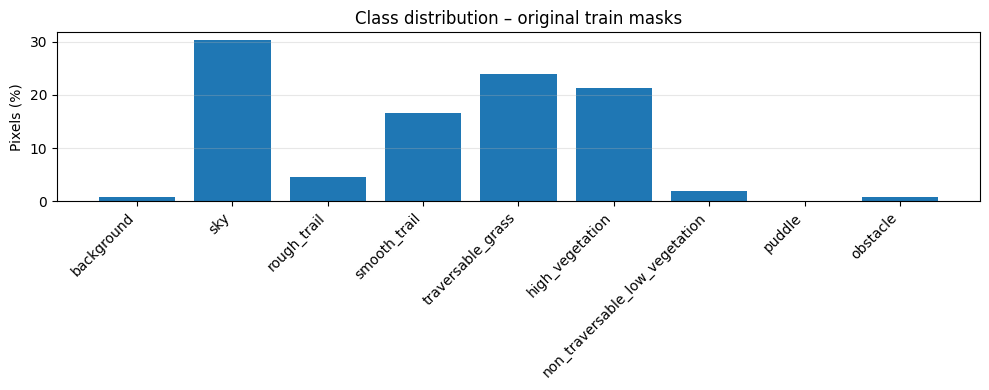

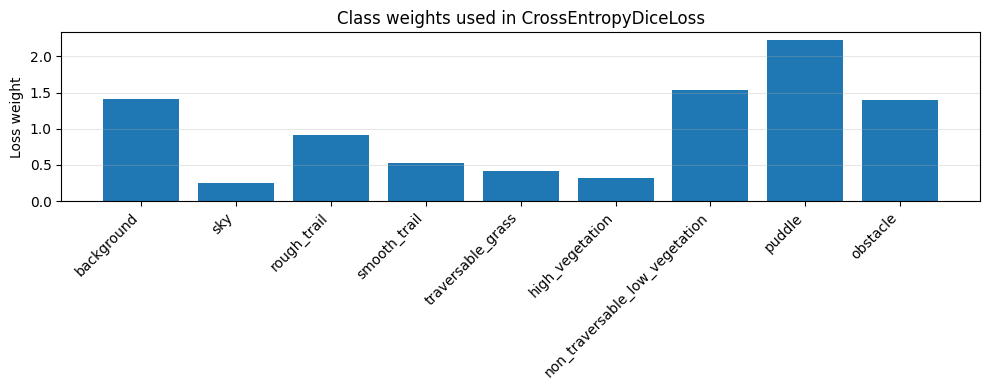

In [ ]:
# visualize class distribution and loss weights (no pandas because it crashed often for no reason)

# 1) distribution
plt.figure(figsize=(10, 4))
plt.bar(CLASS_LIST, CLASS_PERC)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Pixels (%)")
plt.title("Class distribution – original train masks")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) final weights
plt.figure(figsize=(10, 4))
plt.bar(CLASS_LIST, class_weights.cpu().numpy())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Loss weight")
plt.title("Class weights used in CrossEntropyDiceLoss")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import Dataset
from pathlib import Path
import numpy as np
from PIL import Image
import torch

# ImageNet stats for normalization (for pretrained ResNet encoder)
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
imagenet_std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class SegDataset(Dataset):
    """
    Pairs masks and images by stem. For every mask X.png we look
    for X.jpg/jpeg/png in img_dir.

    Augmentations:
      - random horizontal flip (image + mask)
      - simple brightness jitter (image only)
    Then:
      - resize both to 256x256 with PIL
      - normalize image with ImageNet stats
    """

    def __init__(self, img_dir, mask_dir, augment=False):
        self.img_dir  = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.augment  = augment

        self.img_files  = []
        self.mask_files = []

        # build image–mask pairs from masks
        for m in self.mask_dir.glob("*.png"):
            stem = m.stem 
            img_path = None
            for ext in [".jpg", ".jpeg", ".png"]:
                candidate = self.img_dir / f"{stem}{ext}"
                if candidate.exists():
                    img_path = candidate
                    break
            if img_path is not None:
                self.img_files.append(img_path.name)
                self.mask_files.append(m.name)

        tmp = sorted(zip(self.img_files, self.mask_files))
        self.img_files, self.mask_files = zip(*tmp) if tmp else ([], [])

        print(f"[SegDataset] {self.img_dir.name}: {len(self.img_files)} pairs found.")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name  = self.img_files[idx]
        mask_name = self.mask_files[idx]

        img_path  = self.img_dir  / img_name
        mask_path = self.mask_dir / mask_name

        # load PIL images
        img_pil  = Image.open(img_path).convert("RGB")
        mask_pil = Image.open(mask_path).convert("RGB")

        # convert to numpy for augmentations
        img  = np.array(img_pil, dtype=np.uint8)    # (H,W,3)
        mask = np.array(mask_pil, dtype=np.uint8)   # (H,W,3)

        # convert mask RGB to class indices
        mask_idx = mask_rgb_to_idx(mask)           # (H,W) ints

        # simple augmentations
        if self.augment:
            # random horizontal flip
            if np.random.rand() < 0.5:
                img      = np.flip(img, axis=1).copy()
                mask_idx = np.flip(mask_idx, axis=1).copy()

            # brightness jitter (image only)
            if np.random.rand() < 0.3:
                factor = np.random.uniform(0.8, 1.2)
                img = img.astype(np.float32) * factor
                img = np.clip(img, 0, 255).astype(np.uint8)

        # resize
        img_pil_resized  = Image.fromarray(img).resize((384, 384), Image.BILINEAR)
        mask_pil_resized = Image.fromarray(mask_idx.astype(np.uint8)).resize(
            (384, 384), Image.NEAREST
        )

        img_resized  = np.array(img_pil_resized,  dtype=np.float32) / 255.0  # (H,W,3)
        mask_resized = np.array(mask_pil_resized, dtype=np.int64)            # (H,W)

        # normalize image with ImageNet stats
        img_resized = (img_resized - imagenet_mean[None, None, :]) / imagenet_std[None, None, :]

        # to tensors
        img_tensor  = torch.tensor(
            img_resized.transpose(2, 0, 1), dtype=torch.float32
        )  # [3,384,384]
        mask_tensor = torch.tensor(mask_resized, dtype=torch.long)  # [384,384]

        return img_tensor, mask_tensor

In [ ]:
BATCH_SIZE   = 4
NUM_WORKERS  = 2  # set to 0 when you are debugging, future person

train_orig_ds  = SegDataset(TRAIN_ORIG_IMG,  TRAIN_ORIG_MASK,  augment=True)
train_clean_ds = SegDataset(TRAIN_CLEAN_IMG, TRAIN_CLEAN_MASK, augment=True)
val_ds         = SegDataset(VAL_IMG,         VAL_MASK,         augment=False)

train_orig_loader  = DataLoader(train_orig_ds,  batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
train_clean_loader = DataLoader(train_clean_ds, batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader         = DataLoader(val_ds,         batch_size=2,
                                shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(train_orig_ds), len(train_clean_ds), len(val_ds)

[SegDataset] images: 930 pairs found.
[SegDataset] images: 594 pairs found.
[SegDataset] images: 144 pairs found.


(930, 594, 144)

In [ ]:
# ResNet 101

def create_deeplabv3plus():
    model = smp.DeepLabV3Plus(
        encoder_name="resnet101",
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
    )
    return model.to(DEVICE)

# quick sanity check
model_test = create_deeplabv3plus()
print("Model params (M):", sum(p.numel() for p in model_test.parameters()) / 1e6)
del model_test

Downloading: "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth" to /root/.cache/torch/hub/checkpoints/resnet101-5d3b4d8f.pth
100%|██████████| 170M/170M [00:01<00:00, 94.5MB/s] 


Model params (M): 45.671769


In [ ]:
# CE + Dice loss for multi-class segmentation

class CrossEntropyDiceLoss(nn.Module):
    def __init__(self, class_weights=None, smooth=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [B,C,H,W]; targets: [B,H,W] long
        ce_loss = self.ce(logits, targets)

        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)  # [B,C,H,W]

        # one-hot encode targets
        with torch.no_grad():
            one_hot = torch.zeros_like(logits)
            one_hot.scatter_(1, targets.unsqueeze(1), 1)

        dims = (0, 2, 3)
        intersection = (probs * one_hot).sum(dims)
        cardinality  = probs.sum(dims) + one_hot.sum(dims)

        dice_loss_per_class = 1.0 - (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        dice_loss = dice_loss_per_class.mean()

        return ce_loss + dice_loss

In [ ]:
# training utilities

LR     = 3e-4   # base learning rate
EPOCHS = 40     # performs better than 20 and 60

def manual_zero_grad(model):
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()


def manual_sgd_step(model, lr=LR):
    with torch.no_grad():
        for p in model.parameters():
            if p.grad is not None:
                p -= lr * p.grad


def compute_iou_per_class(pred, true, num_classes=NUM_CLASSES):
    """
    pred, true: [B,H,W] int tensors with class indices
    returns: list of IoU per class (float or nan)
    """
    ious = []
    for cls in range(num_classes):
        pred_c = (pred == cls)
        true_c = (true == cls)
        intersection = (pred_c & true_c).sum().item()
        union        = (pred_c | true_c).sum().item()
        if union == 0:
            ious.append(float("nan"))
        else:
            ious.append(intersection / union)
    return ious


def train_one_epoch(model, loader, criterion, lr=LR):
    model.train()
    running_loss = 0.0

    for imgs, masks in loader:
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        manual_zero_grad(model)

        logits = model(imgs)        # [B,C,H,W]
        loss   = criterion(logits, masks)
        loss.backward()

        manual_sgd_step(model, lr=lr)

        running_loss += loss.item()

    return running_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_ious = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, masks)
            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu()
            ious  = compute_iou_per_class(preds, masks.cpu())
            all_ious.append(ious)

    mean_loss = running_loss / len(loader)
    mean_iou  = float(np.nanmean(all_ious))
    return mean_loss, mean_iou


def train_model(train_loader, val_loader, num_epochs=EPOCHS, lr=LR, exp_name="exp"):
    model = create_deeplabv3plus()
    criterion = CrossEntropyDiceLoss(class_weights.to(DEVICE))

    best_mIoU = 0.0
    history = []

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, lr=lr)
        val_loss, val_mIoU = evaluate(model, val_loader, criterion)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mIoU": val_mIoU,
        })

        print(f"Epoch {epoch:02d}: "
              f"train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"mIoU={val_mIoU:.4f}")

        if val_mIoU > best_mIoU:
            best_mIoU = val_mIoU
            torch.save(model.state_dict(), f"{exp_name}_best.pth")
            print(f"  ✅ New best mIoU={best_mIoU:.4f} – saved to {exp_name}_best.pth")

    return model, history

In [20]:
model_orig, history_orig = train_model(
    train_orig_loader,
    val_loader,
    num_epochs=EPOCHS,
    lr=LR,
    exp_name="deeplabv3plus_orig"
)

Epoch 01: train_loss=3.0008  val_loss=2.9734  mIoU=0.0923
  ✅ New best mIoU=0.0923 – saved to deeplabv3plus_orig_best.pth
Epoch 02: train_loss=2.8172  val_loss=2.7754  mIoU=0.1584
  ✅ New best mIoU=0.1584 – saved to deeplabv3plus_orig_best.pth
Epoch 03: train_loss=2.6491  val_loss=2.6436  mIoU=0.2246
  ✅ New best mIoU=0.2246 – saved to deeplabv3plus_orig_best.pth
Epoch 04: train_loss=2.5011  val_loss=2.4613  mIoU=0.2596
  ✅ New best mIoU=0.2596 – saved to deeplabv3plus_orig_best.pth
Epoch 05: train_loss=2.3655  val_loss=2.3625  mIoU=0.2706
  ✅ New best mIoU=0.2706 – saved to deeplabv3plus_orig_best.pth
Epoch 06: train_loss=2.2489  val_loss=2.2501  mIoU=0.2825
  ✅ New best mIoU=0.2825 – saved to deeplabv3plus_orig_best.pth
Epoch 07: train_loss=2.1559  val_loss=2.1595  mIoU=0.2991
  ✅ New best mIoU=0.2991 – saved to deeplabv3plus_orig_best.pth
Epoch 08: train_loss=2.0754  val_loss=2.0887  mIoU=0.3145
  ✅ New best mIoU=0.3145 – saved to deeplabv3plus_orig_best.pth
Epoch 09: train_loss=2.0

In [ ]:
# evaluate best model with per-class IoU

def evaluate_with_per_class(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_ious = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, masks)
            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu()
            ious  = compute_iou_per_class(preds, masks.cpu())
            all_ious.append(ious)

    mean_loss = running_loss / len(loader)
    all_ious = np.array(all_ious)
    per_class_iou = np.nanmean(all_ious, axis=0)

    print("Val loss:", mean_loss)
    for i, name in enumerate(CLASS_NAMES):
        print(f"{i:2d} {name:35s}: {per_class_iou[i]:.3f}")
    print("mIoU:", float(np.nanmean(per_class_iou)))
    return mean_loss, per_class_iou

crit_eval = CrossEntropyDiceLoss(class_weights.to(DEVICE))
evaluate_with_per_class(model_orig, val_loader, crit_eval)

Val loss: 1.7359424498346117
 0 background                         : 0.523
 1 sky                                : 0.801
 2 rough_trail                        : 0.326
 3 smooth_trail                       : 0.306
 4 traversable_grass                  : 0.281
 5 high_vegetation                    : 0.687
 6 non_traversable_low_vegetation     : 0.207
 7 puddle                             : 0.000
 8 obstacle                           : 0.000
mIoU: 0.34786845214129175


(1.7359424498346117,
 array([0.52284419, 0.80082153, 0.32585887, 0.30564427, 0.28108203,
        0.68721004, 0.20735514, 0.        , 0.        ]))

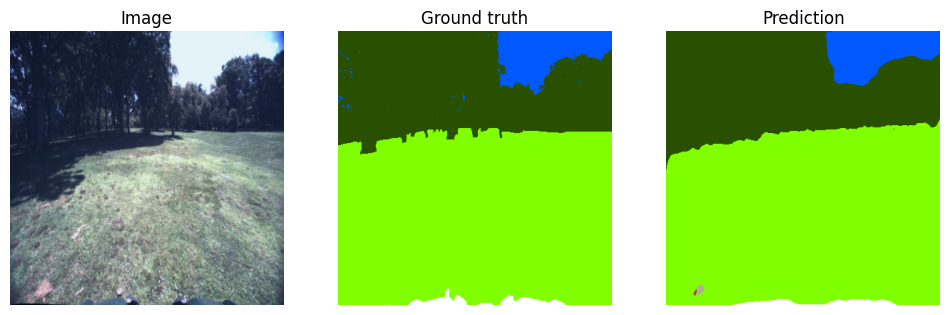

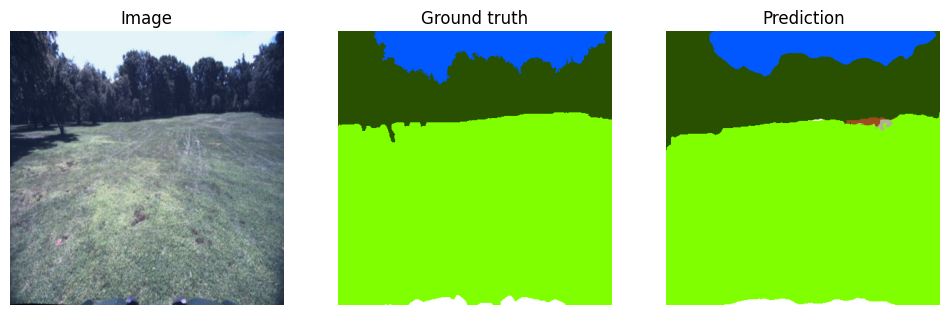

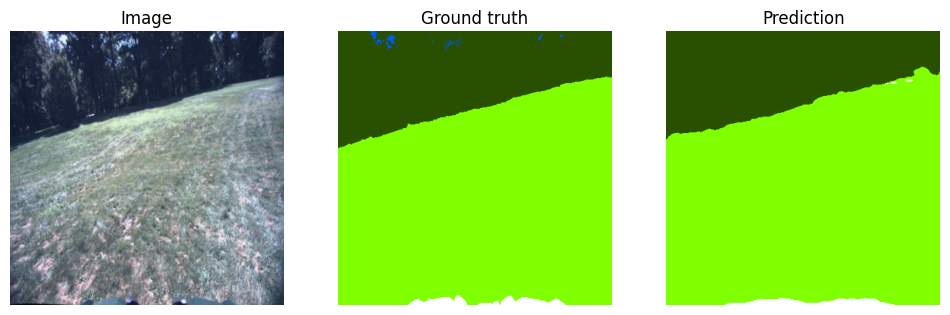

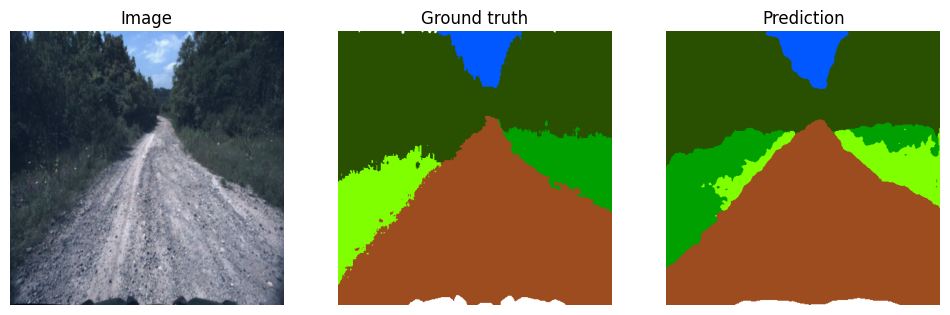

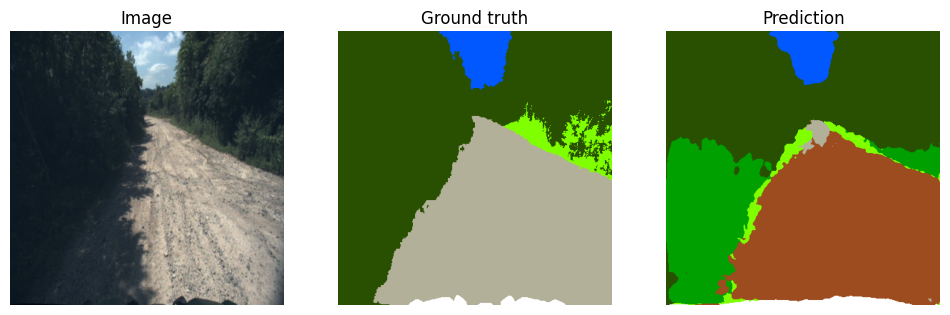

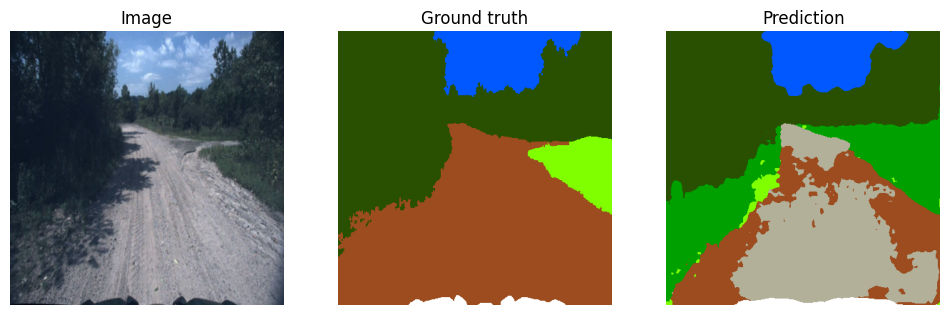

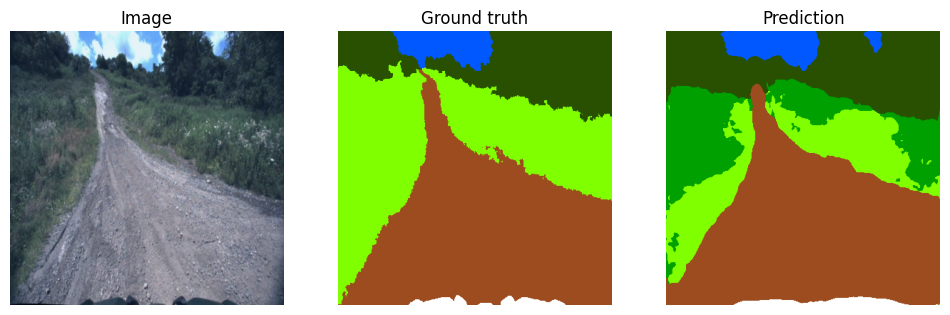

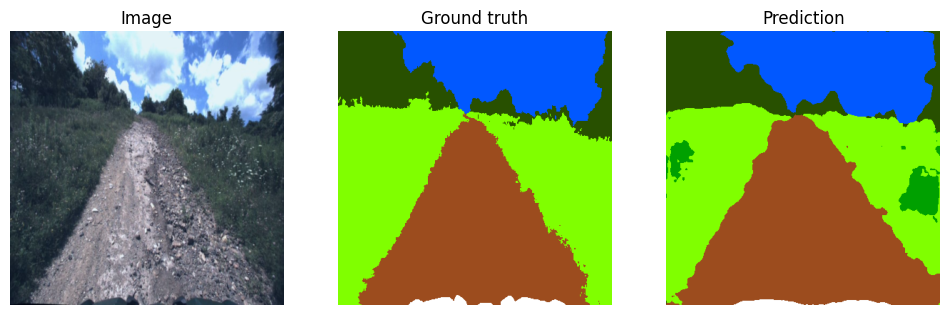

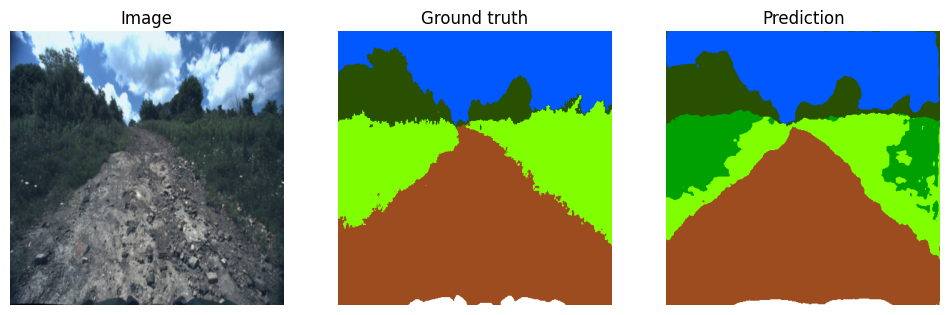

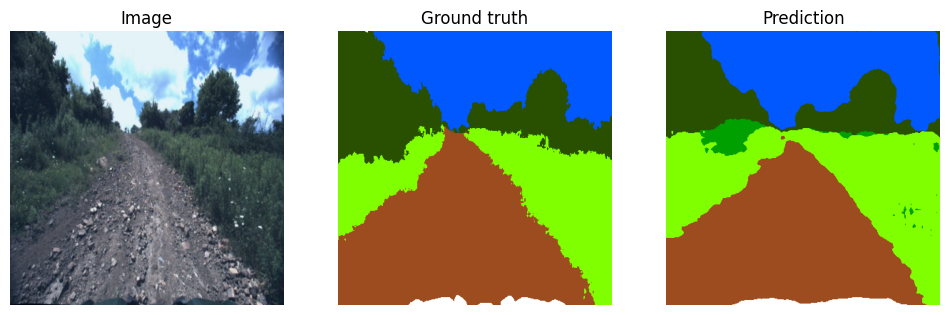

In [22]:
def show_predictions(model, loader, num_imgs=6):
    model.eval()

    imgs_col, gt_col, pr_col = [], [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            preds  = torch.argmax(logits, dim=1).cpu().numpy()

            imgs_col.extend(imgs.cpu())
            gt_col.extend(masks.cpu())
            pr_col.extend(preds)

            if len(imgs_col) >= num_imgs:
                break

    imgs_col = imgs_col[:num_imgs]
    gt_col   = gt_col[:num_imgs]
    pr_col   = pr_col[:num_imgs]

    for i in range(num_imgs):
        # [C,H,W] -> [H,W,C], force plain float32 ndarray
        img = imgs_col[i].numpy().transpose(1, 2, 0)
        img = np.asarray(img, dtype=np.float32)

        # Robust normalization to [0,1] for display
        img_min = float(img.min())
        img_max = float(img.max())
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)
        else:
            img.fill(0.5)  # flat gray if constant

        img = np.clip(img, 0.0, 1.0).astype(np.float32)

        gt  = mask_idx_to_rgb(gt_col[i].numpy())
        pr  = mask_idx_to_rgb(pr_col[i])

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt)
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pr)
        plt.title("Prediction")
        plt.axis("off")

        plt.show()

show_predictions(model_orig, val_loader, num_imgs=10)

In [29]:
crit_eval = CrossEntropyDiceLoss(class_weights.to(DEVICE))
_, per_class_iou = evaluate_with_per_class(model_orig, val_loader, crit_eval)

Val loss: 1.6990035225947697
 0 background                         : 0.456
 1 sky                                : 0.798
 2 rough_trail                        : 0.297
 3 smooth_trail                       : 0.273
 4 traversable_grass                  : 0.309
 5 high_vegetation                    : 0.707
 6 non_traversable_low_vegetation     : 0.179
 7 puddle                             : 0.000
 8 obstacle                           : 0.000
mIoU: 0.3355000894344529
